# 04 — 블랜딩 최종 (3-path OOF 기반 가중치 탐색)

01~03에서 각 경로가 저장한 **unit-level** 예측을 로드해서 가중치를 찾음.

- **입력**: `oof_unit.csv / val_unit.csv / test_unit.csv` (각 경로마다)
- **가중치 기준**: **train OOF unit RMSE** (val/test 비공개라 다른 기준 불가)
- **제약**: `w_i ≥ 0, Σw_i = 1`
- **출력**: `4_output/final/blend/{weights.json, final_val.csv, final_test.csv}`

**로컬 + Colab 양쪽 지원.** Colab 사용 시 `GDRIVE_FINAL_ID` + `GDRIVE_RESULTS_ID` 필요.

## 1. 환경 설정 + 모듈 import

### Colab 사용 가이드
1. `3_modeling/final/` zip → `GDRIVE_FINAL_ID`
2. `4_output/final/` 전체(01/02/03 결과) zip → `GDRIVE_RESULTS_ID`
   - 해제 시 `zit_only/`, `reg_only/{모델}/`, `zit_plus_reg/{모델}/` 구조 유지

In [1]:
import os, sys, json

# ── Colab 사용 시에만 채울 것 ──
GDRIVE_FINAL_ID   = '1HR7LlQmp4n9wGh2WneyVex2mCZ-poiY9'   # ★ final.zip 공유 ID
GDRIVE_RESULTS_ID = ''   # ★ 4_output/final/ 전체 zip 공유 ID (01/02/03 결과)

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip install -q gdown')
        os.system('gdown 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip')
        os.system('unzip -qo /content/code.zip -d /content/project')
        os.makedirs('/content/project/0_data', exist_ok=True)
        os.system('gdown 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip')
        os.system('unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data')
        os.remove('/content/project/0_data/dataset.zip')
    if not os.path.exists('/content/project/3_modeling/final/modules/hpo.py'):
        assert GDRIVE_FINAL_ID, 'GDRIVE_FINAL_ID가 비어있음'
        os.makedirs('/content/project/3_modeling/final', exist_ok=True)
        os.system(f'gdown {GDRIVE_FINAL_ID} -O /content/final.zip')
        os.system('unzip -qo /content/final.zip -d /content/project/3_modeling/final')
    # 01/02/03 결과 (blend 입력)
    _results_dir = '/content/project/4_output/final'
    if not os.path.exists(os.path.join(_results_dir, 'zit_only', 'oof_unit.csv')):
        assert GDRIVE_RESULTS_ID, 'GDRIVE_RESULTS_ID가 비어있음 — 01/02/03 결과 zip 필요'
        os.makedirs(_results_dir, exist_ok=True)
        os.system(f'gdown {GDRIVE_RESULTS_ID} -O /content/results.zip')
        os.system(f'unzip -qo /content/results.zip -d {_results_dir}')
    sys.path.insert(0, '/content/project')
    %run /content/project/setup.py
except ImportError:
    %run ../../setup.py

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from utils.config import PROJECT_ROOT, TARGET_COL, KEY_COL, OUTPUT_DIR
from utils.data import load_all
from utils.evaluate import rmse

MODEL_ROOT = os.path.join(PROJECT_ROOT, "3_modeling")
if MODEL_ROOT not in sys.path:
    sys.path.insert(0, MODEL_ROOT)
from final.modules import blending

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

setup 완료
PROJECT_ROOT = c:\Users\Dell5371\Desktop\기업연계프로젝트


## 2. 블랜딩 설정

- `BLEND_PATHS` : 블랜딩에 포함할 경로 dict. `{name: 경로}` — 경로 하위에 `oof_unit.csv / val_unit.csv / test_unit.csv` 가 있어야 함
- 사용 안 할 경로는 주석 처리
- `BLEND_METHOD` : `'slsqp'` (수학해, 빠름) | `'optuna'` (탐색)

In [2]:
EXP_ID = 'blend-001'
USER   = 'jh'

# ── 블랜딩 대상 경로 (주석 풀어 추가/제거) ──
# 기본값: 이미 실행 완료 가능성이 높은 2개(경로 A + 경로 C LGBM) 활성.
# 실제 사용 시 본인이 실행 완료한 경로만 남기고 나머지는 주석 처리하세요.
_BASE = os.path.join(OUTPUT_DIR, 'final')
BLEND_PATHS = {
    'zit':              os.path.join(_BASE, 'zit_only'),
    'reg_lgbm':         os.path.join(_BASE, 'reg_only', 'lgbm'),
    'reg_xgb':          os.path.join(_BASE, 'reg_only', 'xgb'),
    'reg_catboost':     os.path.join(_BASE, 'reg_only', 'catboost'),
    'reg_et':           os.path.join(_BASE, 'reg_only', 'et'),
    'reg_enet':         os.path.join(_BASE, 'reg_only', 'enet'),
    'zitreg_lgbm':      os.path.join(_BASE, 'zit_plus_reg', 'lgbm'),
    # 'zitreg_xgb':       os.path.join(_BASE, 'zit_plus_reg', 'xgb'),
    # 'zitreg_catboost':  os.path.join(_BASE, 'zit_plus_reg', 'catboost'),
    # 'zitreg_et':        os.path.join(_BASE, 'zit_plus_reg', 'et'),
    # 'zitreg_enet':      os.path.join(_BASE, 'zit_plus_reg', 'enet'),
}

BLEND_METHOD = 'optuna'   # 'slsqp' | 'optuna'
N_TRIALS_OPTUNA = 300    # BLEND_METHOD='optuna'일 때만 사용

# ── 출력 경로 ──
OUT_DIR = os.path.join(_BASE, 'blend')
os.makedirs(OUT_DIR, exist_ok=True)

# ── 경로 존재 확인 (없으면 안내하고 해당 경로만 자동 드랍) ──
_missing = []
for name, _p in list(BLEND_PATHS.items()):
    ok = all(os.path.exists(os.path.join(_p, csv))
             for csv in ('oof_unit.csv', 'val_unit.csv', 'test_unit.csv'))
    if not ok:
        _missing.append((name, _p))
        BLEND_PATHS.pop(name)
if _missing:
    print('[경고] 아래 경로의 unit CSV가 없어 자동 제외:')
    for name, _p in _missing:
        print(f'  - {name:20s}  ← {_p}')
    print('  → 01/02/03 해당 노트북을 먼저 실행해야 합니다.')

print(f'EXP: {EXP_ID} | USER: {USER}')
print(f'BLEND_METHOD: {BLEND_METHOD}')
print(f'블랜딩 대상 경로 ({len(BLEND_PATHS)}개):')
for name, _p in BLEND_PATHS.items():
    print(f'  - {name:20s}  ← {_p}')
print(f'OUT_DIR: {OUT_DIR}')

EXP: blend-001 | USER: jh
BLEND_METHOD: optuna
블랜딩 대상 경로 (7개):
  - zit                   ← c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\zit_only
  - reg_lgbm              ← c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\reg_only\lgbm
  - reg_xgb               ← c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\reg_only\xgb
  - reg_catboost          ← c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\reg_only\catboost
  - reg_et                ← c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\reg_only\et
  - reg_enet              ← c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\reg_only\enet
  - zitreg_lgbm           ← c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\zit_plus_reg\lgbm
OUT_DIR: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\blend


## 3. 데이터 로드 + 각 경로 unit 예측 로드

In [3]:
# ── ys 로드 (train unit RMSE 평가 기준) ──
_, ys = load_all()
ys_train_unit = ys['train'].copy()

# y_train extreme clip (01~03과 동일 조건)
y_raw = ys_train_unit[TARGET_COL]
second_max = y_raw[y_raw < y_raw.max()].max()
ys_train_unit[TARGET_COL] = y_raw.clip(upper=second_max)
print(f'ys_train_unit: {ys_train_unit.shape}')

# ── 각 경로의 OOF/val/test unit 예측 로드 ──
train_preds = {}
val_preds   = {}
test_preds  = {}
for name, path in BLEND_PATHS.items():
    train_preds[name] = pd.read_csv(os.path.join(path, 'oof_unit.csv'))
    val_preds[name]   = pd.read_csv(os.path.join(path, 'val_unit.csv'))
    test_preds[name]  = pd.read_csv(os.path.join(path, 'test_unit.csv'))
    print(f'  {name:20s}  oof={train_preds[name].shape}  '
          f'val={val_preds[name].shape}  test={test_preds[name].shape}')


[load_xs] all-NaN 행 407개 제거 → 174,573행
[load_xs] 4 position 미만 unit 1개 제거 (split별: {'train': 1}) → die 174,573 → 174,572
[load_ys] train: xs에 없는 unit 60개 제거 → 26,187
[load_ys] validation: xs에 없는 unit 22개 제거 → 8,727
[load_ys] test: xs에 없는 unit 20개 제거 → 8,729
Xs: (174572, 1091)  |  Ys: train=26,187, val=8,727, test=8,729
ys_train_unit: (26187, 2)
  zit                   oof=(26187, 3)  val=(8727, 3)  test=(8729, 3)
  reg_lgbm              oof=(26187, 2)  val=(8727, 2)  test=(8729, 2)
  reg_xgb               oof=(26187, 2)  val=(8727, 2)  test=(8729, 2)
  reg_catboost          oof=(26187, 3)  val=(8727, 3)  test=(8729, 3)
  reg_et                oof=(26187, 3)  val=(8727, 3)  test=(8729, 3)
  reg_enet              oof=(26187, 3)  val=(8727, 3)  test=(8729, 3)
  zitreg_lgbm           oof=(26187, 3)  val=(8727, 3)  test=(8729, 3)


## 4. 블랜딩 (가중치 탐색 + val/test 적용)

- train OOF 기준으로 가중치 탐색 (val/test 비공개)
- 동일 가중치를 val/test 예측에 적용

In [4]:
assert len(BLEND_PATHS) >= 2, (
    f'블랜딩엔 최소 2개 경로 필요 (현재 {len(BLEND_PATHS)}개). '
    '1개면 그 경로의 unit CSV를 그대로 제출하면 됩니다. '
    '주석 풀어 경로 추가하거나, 01/02/03 노트북 먼저 실행하세요.'
)

result = blending.fit_and_apply(
    train_preds=train_preds,
    val_preds=val_preds,
    test_preds=test_preds,
    y_train_unit=ys_train_unit,
    method=BLEND_METHOD,
    n_trials=N_TRIALS_OPTUNA,
)

weights      = result['weights']
train_blend  = result['train_blend']
val_blend    = result['val_blend']
test_blend   = result['test_blend']
train_rmse   = result['train_rmse']
study        = result.get('study', None)   # optuna일 때만 존재

print(f'\n[Blending 완료]')
print(f'  method:      {result["method"]}')
print(f'  train RMSE:  {train_rmse:.6f}')
print(f'  weights:')
for n, w in weights.items():
    print(f'    {n:20s}  {w:.4f}')

[I 2026-04-26 16:30:27,605] A new study created in memory with name: no-name-86990ec5-df44-4464-8f13-36a7c76d5d22
[I 2026-04-26 16:30:27,606] Trial 0 finished with value: 0.005553390819259159 and parameters: {'w_zit': 0.37460266483547777, 'w_reg_lgbm': 0.9507192349792751, 'w_reg_xgb': 0.7320207424172239, 'w_reg_catboost': 0.5986986183486169, 'w_reg_et': 0.15610303857839228, 'w_reg_enet': 0.15607892088416903, 'w_zitreg_lgbm': 0.05817780380698265}. Best is trial 0 with value: 0.005553390819259159.
[I 2026-04-26 16:30:27,608] Trial 1 finished with value: 0.005535770303085665 and parameters: {'w_zit': 0.8661895281603577, 'w_reg_lgbm': 0.6011549002420344, 'w_reg_xgb': 0.7081017705382658, 'w_reg_catboost': 0.020682435846372867, 'w_reg_et': 0.9699128611767781, 'w_reg_enet': 0.8324593965363417, 'w_zitreg_lgbm': 0.21241787676720833}. Best is trial 1 with value: 0.005535770303085665.
[I 2026-04-26 16:30:27,609] Trial 2 finished with value: 0.005524474014180012 and parameters: {'w_zit': 0.1819067

[blend Optuna] weights={'zit': 0.6106, 'reg_lgbm': 0.0014, 'reg_xgb': 0.0004, 'reg_catboost': 0.3233, 'reg_et': 0.0253, 'reg_enet': 0.0135, 'zitreg_lgbm': 0.0255}, rmse=0.005505

[Blending 완료]
  method:      optuna
  train RMSE:  0.005505
  weights:
    zit                   0.6106
    reg_lgbm              0.0014
    reg_xgb               0.0004
    reg_catboost          0.3233
    reg_et                0.0253
    reg_enet              0.0135
    zitreg_lgbm           0.0255


## 4-1. val/test RMSE 모니터링 (블랜딩 효과 + 길이 검증)

- 각 path 단독 vs 블랜딩 후 RMSE 비교
- blend 결과와 ys 길이가 안 맞으면 ⚠ 경고 (silent failure 방지)

In [5]:
# ── 각 path 단독 RMSE (블랜딩 효과 비교용) ──
# 주의: 일부 path의 unit CSV는 자체 health 컬럼을 포함 → merge 시 컬럼 충돌 방지 위해 [KEY, pred]만 추출
solo_rmse = {'train': {}, 'val': {}, 'test': {}}

print(f'── 각 path 단독 train OOF RMSE ──')
_y = ys_train_unit.set_index(KEY_COL)[TARGET_COL]
for path_name, df in train_preds.items():
    p = df.set_index(KEY_COL)['pred'].loc[_y.index]
    r = float(np.sqrt(np.mean((p.values - _y.values) ** 2)))
    solo_rmse['train'][path_name] = r
    print(f'  {path_name:20s}  RMSE = {r:.6f}')

print(f'\n── 각 path 단독 val/test OOF RMSE ──')
for nm, preds_d, ys_key in [('val', val_preds, 'validation'),
                            ('test', test_preds, 'test')]:
    ys_eval = ys[ys_key]
    print(f'  [{nm}]')
    for path_name, df in preds_d.items():
        merged = df[[KEY_COL, 'pred']].merge(ys_eval, on=KEY_COL, how='inner')
        r = rmse(merged[TARGET_COL].values, merged['pred'].values)
        solo_rmse[nm][path_name] = r
        print(f'    {path_name:20s}  RMSE = {r:.6f}  (n={len(merged):,})')

# ── 블랜딩 후 val/test RMSE + 길이 mismatch 감지 ──
print(f'\n── 블랜딩 후 val/test RMSE ──')
blend_rmse = {'train': train_rmse}
for nm, blend, ys_key in [('val', val_blend, 'validation'),
                          ('test', test_blend, 'test')]:
    ys_eval = ys[ys_key]
    merged = blend[[KEY_COL, 'pred']].merge(ys_eval, on=KEY_COL, how='inner')
    if len(merged) != len(blend) or len(merged) != len(ys_eval):
        print(f'  ⚠ {nm}: blend={len(blend)}, ys={len(ys_eval)}, '
              f'merged={len(merged)} (불일치! 일부 unit 평가 누락 가능)')
    r = rmse(merged[TARGET_COL].values, merged['pred'].values)
    blend_rmse[nm] = r
    print(f'  {nm:5s} blended  RMSE = {r:.6f}  (n={len(merged):,})')

val_rmse_blend  = blend_rmse['val']
test_rmse_blend = blend_rmse['test']

print(f'\n── 블랜딩 vs 단독 최저 ──')
for nm in ('train','val','test'):
    best_solo_name = min(solo_rmse[nm], key=solo_rmse[nm].get)
    best_solo_r    = solo_rmse[nm][best_solo_name]
    delta = blend_rmse[nm] - best_solo_r
    sym = '↓' if delta < 0 else '↑'
    print(f'  {nm:5s}  blend={blend_rmse[nm]:.6f}  best_solo={best_solo_r:.6f}({best_solo_name})  {sym}{abs(delta):.6f}')

── 각 path 단독 train OOF RMSE ──
  zit                   RMSE = 0.005503
  reg_lgbm              RMSE = 0.005527
  reg_xgb               RMSE = 0.005947
  reg_catboost          RMSE = 0.005527
  reg_et                RMSE = 0.005542
  reg_enet              RMSE = 0.005563
  zitreg_lgbm           RMSE = 0.005572

── 각 path 단독 val/test OOF RMSE ──
  [val]
    zit                   RMSE = 0.005709  (n=8,727)
    reg_lgbm              RMSE = 0.005733  (n=8,727)
    reg_xgb               RMSE = 0.006138  (n=8,727)
    reg_catboost          RMSE = 0.005742  (n=8,727)
    reg_et                RMSE = 0.005756  (n=8,727)
    reg_enet              RMSE = 0.005781  (n=8,727)
    zitreg_lgbm           RMSE = 0.005766  (n=8,727)
  [test]
    zit                   RMSE = 0.008414  (n=8,729)
    reg_lgbm              RMSE = 0.008430  (n=8,729)
    reg_xgb               RMSE = 0.008741  (n=8,729)
    reg_catboost          RMSE = 0.008437  (n=8,729)
    reg_et                RMSE = 0.008453  (n=8,729)
 

## 5. 최종 결과 저장

In [6]:
# weights.json
meta = {
    'exp_id':      EXP_ID,
    'user':        USER,
    'method':      BLEND_METHOD,
    'paths':       {k: v for k, v in BLEND_PATHS.items()},
    'weights':     weights,
    'train_rmse':  train_rmse,
    'val_rmse':    val_rmse_blend,
    'test_rmse':   test_rmse_blend,
    'solo_rmse':   solo_rmse,
}
with open(os.path.join(OUT_DIR, 'weights.json'), 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False, default=str)

# 예측 CSV (KEY_COL + pred)
train_blend.to_csv(os.path.join(OUT_DIR, 'final_train_oof.csv'), index=False)
val_blend.to_csv(  os.path.join(OUT_DIR, 'final_val.csv'),       index=False)
test_blend.to_csv( os.path.join(OUT_DIR, 'final_test.csv'),      index=False)

# 제출 형식 (ufs_serial, health) — test 예측만
submission = test_blend.rename(columns={'pred': TARGET_COL})
submission.to_csv(os.path.join(OUT_DIR, 'submission.csv'), index=False)

print(f'[저장 완료] {OUT_DIR}')
for f in sorted(os.listdir(OUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f'  {f:30s}  {size_kb:10,.1f} KB')

[저장 완료] c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\blend
  final_test.csv                       252.7 KB
  final_train_oof.csv                  758.4 KB
  final_val.csv                        252.6 KB
  submission.csv                       252.7 KB
  weights.json                           2.1 KB


## 6. 요약

In [ ]:
print(f'★ 04 블랜딩 최종')
print(f'  EXP_ID       : {EXP_ID}')
print(f'  method       : {BLEND_METHOD}')
print(f'  경로 수       : {len(BLEND_PATHS)}')
print(f'  train RMSE   : {train_rmse:.6f}  (블랜딩 후 train OOF 기준)')
print(f'  val   RMSE   : {val_rmse_blend:.6f}  (블랜딩 후)')
print(f'  test  RMSE   : {test_rmse_blend:.6f}  (블랜딩 후)')
print(f'  weights:')
for n, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f'    {n:20s}  {w:.4f}')
print(f'\n제출 파일: {os.path.join(OUT_DIR, "submission.csv")}')

★ 04 블랜딩 최종
  EXP_ID       : blend-001
  method       : optuna
  경로 수       : 7
  train RMSE   : 0.005505  (블랜딩 후 train OOF 기준)
  val   RMSE   : 0.005715  (블랜딩 후)
  test  RMSE   : 0.008418  (블랜딩 후)
  weights:
    zit                   0.6106
    reg_catboost          0.3233
    zitreg_lgbm           0.0255
    reg_et                0.0253
    reg_enet              0.0135
    reg_lgbm              0.0014
    reg_xgb               0.0004

제출 파일: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\blend\submission.csv


## 7. 시각화 (Optuna history + 가중치 + RMSE 비교)

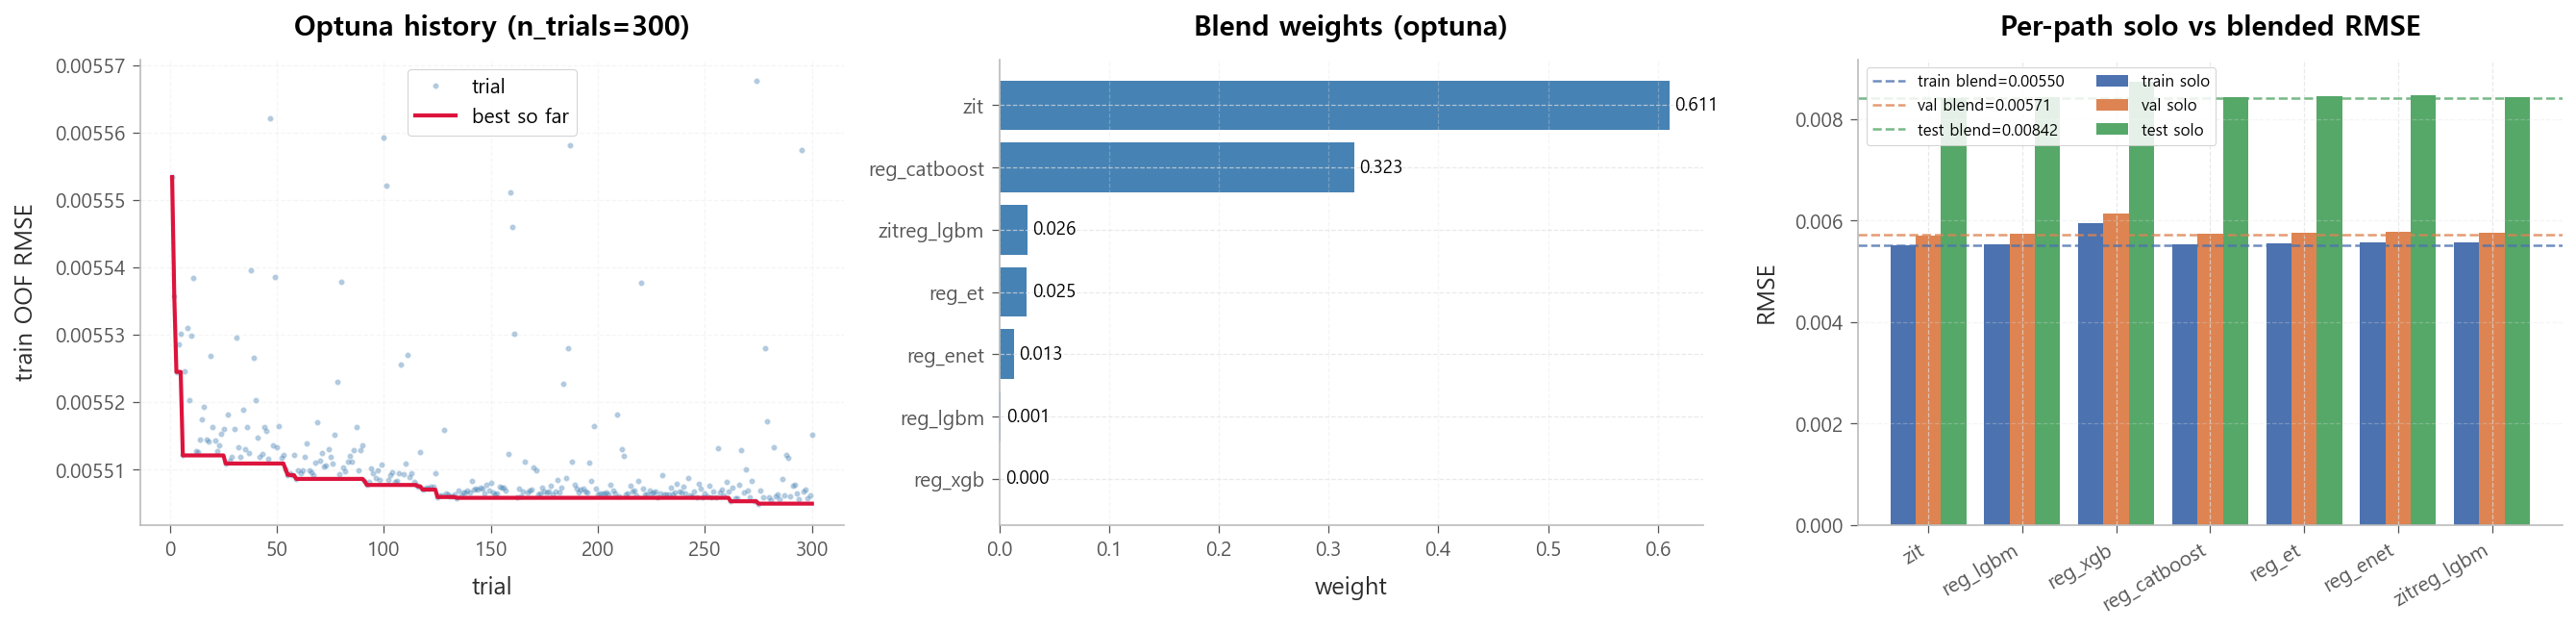

[저장] c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\blend\blend_summary.png


In [ ]:
import matplotlib.pyplot as plt

n_panels = 3 if study is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4.5))
if n_panels == 2:
    axes = list(axes)

# ── (1) Optuna trial history (best-so-far) ──
if study is not None:
    ax = axes[0]
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(vals)
    ax.plot(range(1, len(vals)+1), vals, 'o', ms=2, alpha=0.3, color='steelblue', label='trial')
    ax.plot(range(1, len(best_so_far)+1), best_so_far, '-', lw=2, color='crimson', label='best so far')
    ax.set_xlabel('trial')
    ax.set_ylabel('train OOF RMSE')
    ax.set_title(f'Optuna history (n_trials={len(vals)})')
    ax.legend()
    ax.grid(alpha=0.3)
    ax_idx = 1
else:
    ax_idx = 0

# ── (2) 가중치 bar (내림차순) ──
ax = axes[ax_idx]
sorted_w = sorted(weights.items(), key=lambda x: -x[1])
names = [n for n, _ in sorted_w]
vals  = [w for _, w in sorted_w]
ax.barh(range(len(names)), vals, color='steelblue')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel('weight')
ax.set_title(f'Blend weights ({BLEND_METHOD})')
for i, v in enumerate(vals):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.grid(alpha=0.3, axis='x')

# ── (3) 경로별 RMSE (train/val/test) + 블랜딩 baseline ──
ax = axes[ax_idx + 1]
path_names = list(BLEND_PATHS.keys())
x = np.arange(len(path_names))
width = 0.27
for i, nm in enumerate(('train', 'val', 'test')):
    rs = [solo_rmse[nm][n] for n in path_names]
    ax.bar(x + (i - 1) * width, rs, width, label=f'{nm} solo')
colors = ['C0', 'C1', 'C2']
for nm, c in zip(('train', 'val', 'test'), colors):
    ax.axhline(blend_rmse[nm], ls='--', lw=1.2, color=c, alpha=0.8,
               label=f'{nm} blend={blend_rmse[nm]:.5f}')
ax.set_xticks(x)
ax.set_xticklabels(path_names, rotation=30, ha='right')
ax.set_ylabel('RMSE')
ax.set_title('Per-path solo vs blended RMSE')
ax.legend(loc='best', fontsize=8, ncol=2)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'blend_summary.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'[저장] ' + os.path.join(OUT_DIR, 'blend_summary.png'))